<a href="https://colab.research.google.com/github/eduzegarra/grade_01/blob/main/Ollas_prueba.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [232]:
!python generate_lima_datasets.py

Generating synthetic INEI Census Blocks...
Generating formal Comedores Populares points...
Generating Ollas Comunes points and modeling survival...
Exported: inei_manzanas_sample.geojson (144 features)
Exported: comedores_populares_sample.geojson (35 features)
Exported: ollas_comunes_sample.geojson (110 features)

All datasets generated successfully and ready for Google Colab testing.


In [233]:
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
# 2. Ingest the generated GeoJSON files
gdf_censo = gpd.read_file("inei_manzanas_sample.geojson")
gdf_comedores = gpd.read_file("comedores_populares_sample.geojson")
gdf_ollas = gpd.read_file("ollas_comunes_sample.geojson")

In [234]:
gdf_ollas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID_OLLA                 110 non-null    object        
 1   NOMBRE                  110 non-null    object        
 2   BENEFICIARIOS           110 non-null    int32         
 3   TIPO_COMBUSTIBLE        110 non-null    object        
 4   FECHA_REGISTRO          110 non-null    datetime64[ms]
 5   dist_nearest_comedor_m  110 non-null    float64       
 6   ESTADO                  110 non-null    object        
 7   geometry                110 non-null    geometry      
dtypes: datetime64[ms](1), float64(1), geometry(1), int32(1), object(4)
memory usage: 6.6+ KB


In [235]:
gdf_ollas.describe()

,BENEFICIARIOS,FECHA_REGISTRO,dist_nearest_comedor_m
count,110.000000,110,110.000000
mean,56.045455,2020-08-14 17:27:16.363000,757.813392
min,27.000000,2020-04-12 00:00:00,58.430732
25%,48.000000,2020-04-12 00:00:00,464.393920
50%,55.500000,2020-09-18 00:00:00,706.126693
75%,64.750000,2020-09-18 00:00:00,1007.486165
max,87.000000,2021-02-04 00:00:00,2032.570161
std,11.625965,NaN,407.126343


<Axes: ylabel='Density'>

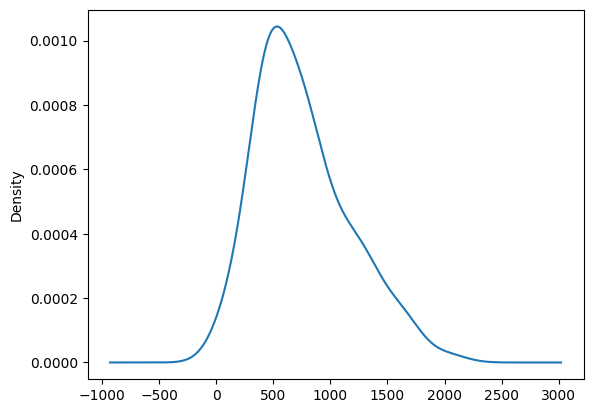

In [236]:
gdf_ollas.dist_nearest_comedor_m.plot(kind='kde')

In [237]:
gdf_comedores.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ID_COMEDOR     35 non-null     object  
 1   NOMBRE         35 non-null     object  
 2   BENEFICIARIOS  35 non-null     int32   
 3   ESTADO         35 non-null     object  
 4   geometry       35 non-null     geometry
dtypes: geometry(1), int32(1), object(3)
memory usage: 1.4+ KB


<Axes: ylabel='Frequency'>

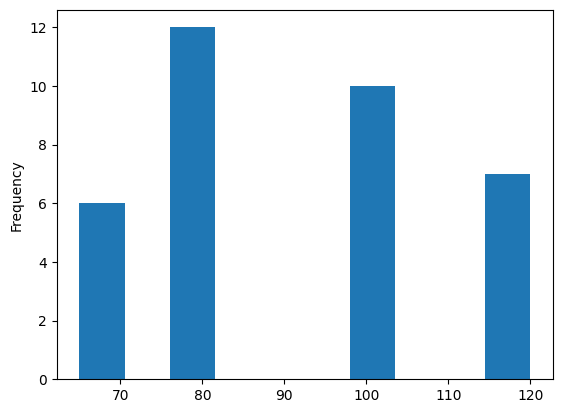

In [238]:
gdf_comedores.BENEFICIARIOS.plot(kind='hist')

In [239]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      144 non-null    object  
 1   POB_TOTAL       144 non-null    int32   
 2   NBI_AGUA_PCT    144 non-null    float64 
 3   NBI_HACINA_PCT  144 non-null    float64 
 4   ESTRATO_SE      144 non-null    object  
 5   geometry        144 non-null    geometry
dtypes: float64(2), geometry(1), int32(1), object(2)
memory usage: 6.3+ KB


In [240]:
gdf_censo.POB_TOTAL.describe()

,POB_TOTAL
count,144.000000
mean,278.506944
std,48.884050
min,164.000000
25%,240.750000
50%,280.500000
75%,317.000000
max,416.000000


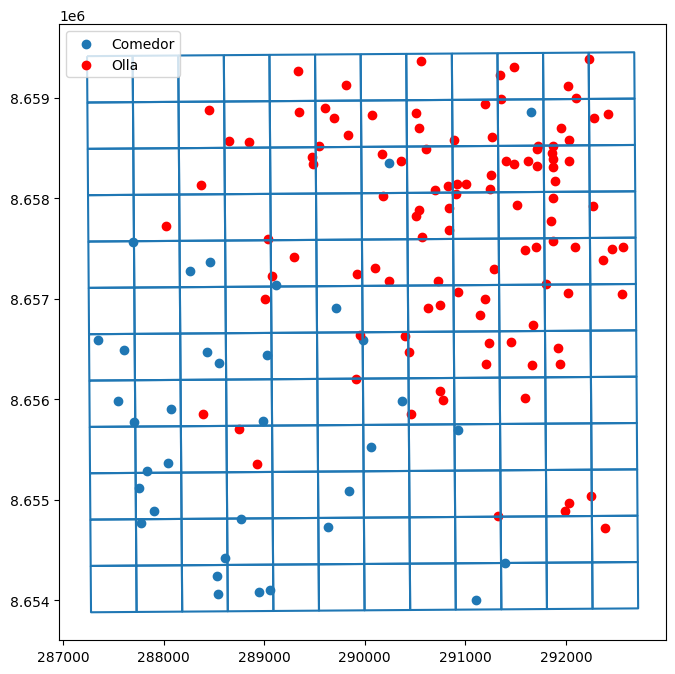

In [241]:
axis=gdf_censo.boundary.plot(figsize=(15,8))
gdf_comedores.plot(ax=axis, label='Comedor')
gdf_ollas.plot(ax=axis, color='red', label='Olla')
axis.legend()
plt.show()

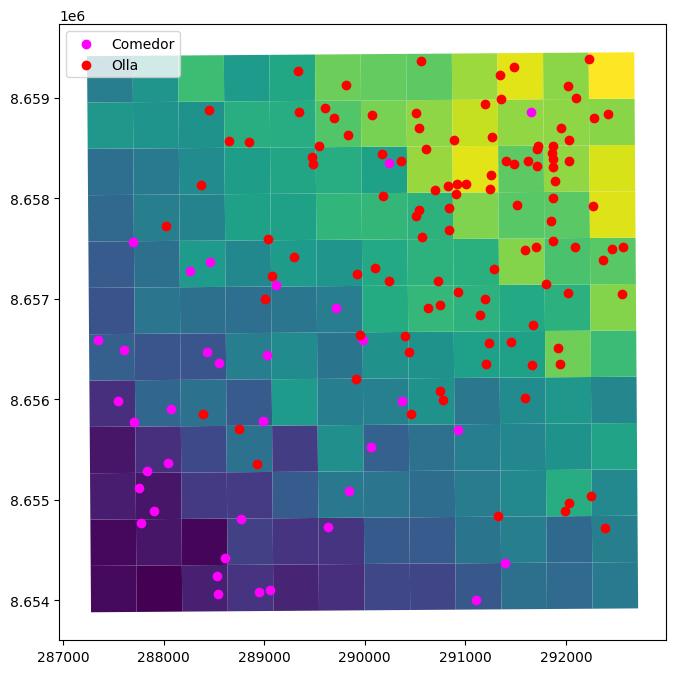

In [242]:
axis=gdf_censo.plot(column='NBI_AGUA_PCT',figsize=(15,8))
gdf_comedores.plot(ax=axis, label='Comedor', color='magenta')
gdf_ollas.plot(ax=axis, color='red', label='Olla')
axis.legend()
plt.show()

In [243]:
joined = gpd.sjoin(gdf_ollas, gdf_censo, how="left", predicate="intersects")

In [184]:
joined.columns

Index(['ID_OLLA', 'NOMBRE', 'BENEFICIARIOS', 'TIPO_COMBUSTIBLE',
       'FECHA_REGISTRO', 'dist_nearest_comedor_m', 'ESTADO', 'geometry',
       'index_right', 'ID_MANZANA', 'POB_TOTAL', 'NBI_AGUA_PCT',
       'NBI_HACINA_PCT', 'ESTRATO_SE'],
      dtype='object')

In [244]:
joined=joined.rename(columns={'ID_OLLA':'num_ollas','dist_nearest_comedor_m':'d_olla_comedor'}).groupby('ID_MANZANA').agg({'num_ollas':'count','d_olla_comedor':'mean'})

In [245]:
gdf_censo=gdf_censo.merge(joined, on='ID_MANZANA', how='left')

In [246]:
len(gdf_censo)

144

In [247]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      144 non-null    object  
 1   POB_TOTAL       144 non-null    int32   
 2   NBI_AGUA_PCT    144 non-null    float64 
 3   NBI_HACINA_PCT  144 non-null    float64 
 4   ESTRATO_SE      144 non-null    object  
 5   geometry        144 non-null    geometry
 6   num_ollas       57 non-null     float64 
 7   d_olla_comedor  57 non-null     float64 
dtypes: float64(4), geometry(1), int32(1), object(2)
memory usage: 8.6+ KB


In [248]:
# Finds the closest feature in 'comedores' for each row in 'grid_base'
temp=gpd.sjoin_nearest(gdf_censo,gdf_comedores,how="left", distance_col="d_comedor")

In [249]:
gdf_censo=temp.drop_duplicates(subset='ID_MANZANA')

In [250]:
gdf_censo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID_MANZANA      144 non-null    object  
 1   POB_TOTAL       144 non-null    int32   
 2   NBI_AGUA_PCT    144 non-null    float64 
 3   NBI_HACINA_PCT  144 non-null    float64 
 4   ESTRATO_SE      144 non-null    object  
 5   geometry        144 non-null    geometry
 6   num_ollas       57 non-null     float64 
 7   d_olla_comedor  57 non-null     float64 
 8   index_right     144 non-null    int64   
 9   ID_COMEDOR      144 non-null    object  
 10  NOMBRE          144 non-null    object  
 11  BENEFICIARIOS   144 non-null    int32   
 12  ESTADO          144 non-null    object  
 13  d_comedor       144 non-null    float64 
dtypes: float64(5), geometry(1), int32(2), int64(1), object(5)
memory usage: 15.8+ KB


In [255]:
gdf_censo.loc[gdf_censo.num_ollas.isna(), 'num_ollas']=0

<Axes: ylabel='Frequency'>

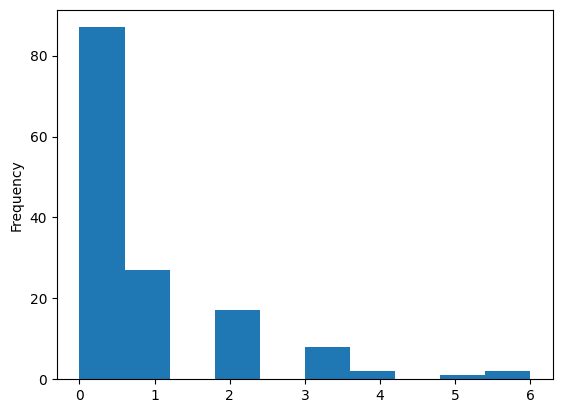

In [257]:
gdf_censo.num_ollas.plot(kind='hist')

In [270]:
gdf_censo.describe()

,POB_TOTAL,NBI_AGUA_PCT,NBI_HACINA_PCT,num_ollas,d_olla_comedor,index_right,BENEFICIARIOS,d_comedor,distance
count,144.000000,144.000000,144.000000,144.000000,57.000000,144.000000,144.000000,144.000000,144.0
mean,278.506944,40.204861,19.289444,0.763889,794.368559,14.187500,87.291667,402.221910,0.0
std,48.884050,18.684505,9.328933,1.217507,432.764120,8.745803,17.816813,429.129418,0.0
min,164.000000,2.000000,4.000000,0.000000,113.461677,0.000000,65.000000,0.000000,0.0
25%,240.750000,28.675000,12.552500,0.000000,465.119538,7.750000,80.000000,34.459239,0.0
50%,280.500000,39.590000,19.570000,0.000000,741.095015,11.000000,80.000000,270.753459,0.0
75%,317.000000,52.705000,25.937500,1.000000,1055.598229,21.000000,100.000000,666.542901,0.0
max,416.000000,81.340000,45.800000,6.000000,2032.570161,34.000000,120.000000,1647.099164,0.0


In [277]:
gdf_censo['distance']=0

In [280]:
gdf_censo.loc[gdf_censo['d_olla_comedor'].isna(),'distance']=gdf_censo['d_comedor']

/tmp/ipykernel_1348/352861812.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 430.45281171   46.22399018   33.72116721   49.48680324    0.
    0.           54.79329624    0.            9.63625711  470.63959108
  931.64279476 1392.64586819  351.79019775    0.            0.
    0.            0.          109.26907897  190.20484191    8.68796682
  470.71982933  931.68334847 1392.67300228    0.            0.
  140.20657403  129.34982238    0.          158.85607831    0.
  213.00112435 1467.37180339    0.            0.            6.91069716
    0.            0.           53.10427527  691.64122022 1338.37660883
   32.17789205   99.61155815  134.64030654  101.78219146   87.98958112
   44.09763326   13.1294795   447.87055146  370.41600782    0.
    0.           71.17190465  229.45435723    0.          409.15851762
  277.96040847  512.32897967  307.80340458  150.62388351    0.
    0.           75.89041015  6

<Axes: ylabel='Density'>

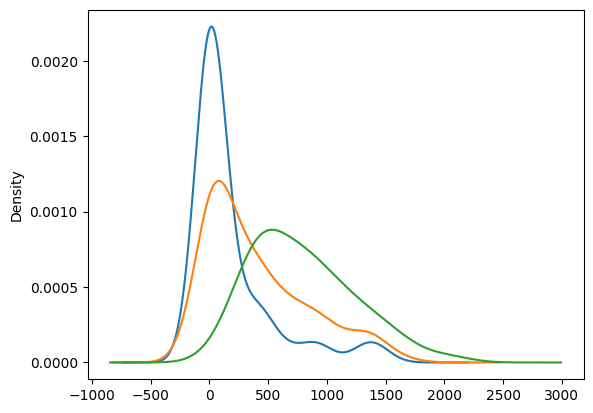

In [285]:
gdf_censo['distance'].plot(kind='kde')
gdf_censo['d_comedor'].plot(kind='kde')
gdf_censo['d_olla_comedor'].plot(kind='kde')